# Triển khai Pipeline Machine Learning Toàn diện cho 2 Bài toán Kaggle

1. **Hệ thống Dự báo Nhu cầu Sử dụng Phương tiện (Bike Sharing Dataset - `hour.csv`):**
   * **Phân loại bài toán:** Hồi quy (Regression).
   * **Biến mục tiêu ($y$):** `cnt` (Tổng số lượt thuê xe trong một giờ cụ thể).
   * **Ý nghĩa thực tế:** Giúp các doanh nghiệp quản lý đội xe (fleet management) tối ưu hóa việc phân bổ phương tiện đến các trạm theo thời gian thực, giảm thiểu tình trạng thiếu hụt hoặc dư thừa xe tại các điểm nóng, từ đó tối ưu hóa chi phí vận hành và nâng cao trải nghiệm khách hàng.

2. **Mô hình Dự báo Tỷ lệ Khách hàng Rời bỏ Dịch vụ (Telco Customer Churn Dataset):**
   * **Phân loại bài toán:** Phân loại nhị phân (Binary Classification).
   * **Biến mục tiêu ($y$):** `Churn` (Khách hàng có rời bỏ dịch vụ viễn thông hay không - `Yes`/`No`).
   * **Ý nghĩa thực tế:** Giúp bộ phận Chăm sóc khách hàng (CRM) chủ động nhận diện các nhóm khách hàng có nguy cơ rời dịch vụ cao để đưa ra các chương trình tiếp thị cá nhân hóa hoặc chính sách ưu đãi phù hợp. Việc dự báo churn giúp tối thiểu hóa **Chi phí Giữ chân Khách hàng (Customer Retention Cost - CRC)** và tối đa hóa **Giá trị Trọn đời Khách hàng (Customer Lifetime Value - CLV)**.



## 0. Thiết lập Môi trường và Import Thư viện Hệ thống

Để xây dựng một pipeline chuẩn hóa, chúng ta cần chuẩn bị môi trường lập trình đồng bộ:
1. **Quản lý dependencies:** Cài đặt các thư viện lõi thông qua `%pip`.
2. **Import có cấu trúc:** Phân nhóm các thư viện rõ ràng (Xử lý dữ liệu, Trực quan hóa, Tiền xử lý, Mô hình hóa, Đánh giá sai số).
3. **Cố định hạt giống ngẫu nhiên (Reproducibility):** Cố định hạt giống ngẫu nhiên (`RANDOM_STATE = 42`) cho cả NumPy, Scikit-learn và các bộ chia dữ liệu để đảm bảo mọi kết quả huấn luyện và đánh giá đều có khả năng tái lập 100% trong các lần chạy khác nhau.
4. **Cấu hình hiển thị:** Thiết lập hiển thị số thực với độ chính xác cao và tối ưu hóa bảng biểu của Pandas để hỗ trợ việc phân tích báo cáo.


In [ ]:
%pip install -q kagglehub pandas numpy matplotlib seaborn scikit-learn scipy joblib

In [ ]:
from pathlib import Path
import warnings
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import loguniform
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
    accuracy_score, average_precision_score, classification_report,
    f1_score, mean_absolute_error, mean_squared_error, precision_recall_curve,
    precision_score, r2_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, TimeSeriesSplit, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid')

### Thiết kế các Hàm Tiện ích Hệ thống (Utility Functions)

Để đảm bảo tính tái sử dụng cao, tránh lặp lại mã nguồn (nguyên tắc DRY - Don't Repeat Yourself) và giữ cho luồng code của pipeline luôn mạch lạc, chúng ta đóng gói các chức năng bổ trợ thành các hàm tiện ích chuyên biệt:

1. **`download_dataset` & `find_csv`:** Đóng gói cơ chế tải dữ liệu tự động từ KaggleHub API và định vị tệp dữ liệu đích dạng `.csv` trong cây thư mục đệ quy. Chức năng này loại bỏ hoàn toàn các lỗi đường dẫn tương đối khi di chuyển notebook giữa các môi trường chạy khác nhau.
2. **`make_ohe`:** Khởi tạo `OneHotEncoder` một cách an sau. Hàm này tự động phát hiện và xử lý sự khác biệt về mặt tham số giữa các phiên bản Scikit-learn cũ (sử dụng tham số `sparse=False`) và mới (sử dụng `sparse_output=False`), ngăn ngừa lỗi dừng chương trình không mong muốn.
3. **`show_missing`:** Tính toán thống kê dữ liệu khuyết thiếu một cách trực quan, trả về cả số lượng tuyệt đối và tỷ lệ phần trăm tương đối, sắp xếp theo thứ tự giảm dần để nhà phát triển lập tức nhận diện cột dữ liệu cần xử lý.
4. **`regression_metrics`:** Gom các chỉ số đo lường sai số hồi quy kinh điển: MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), và $R^2$ Score vào một cấu trúc thống nhất phục vụ việc so sánh mô hình.
5. **`positive_expm1`:** Hàm nghịch đảo an toàn của phép biến đổi $\log(y + 1)$ cho biến mục tiêu. Việc sử dụng `np.maximum(0, ...)` đảm bảo rằng mô hình không bao giờ đưa ra các dự báo số lượng thuê xe âm (điều phi lý về mặt thực tế vật lý).
6. **`classification_metrics`:** Hàm tính toán hiệu năng phân loại dựa trên một ngưỡng phân định xác suất tùy chỉnh (Decision Threshold $\tau$). Hàm đo lường chi tiết: Accuracy, Precision, Recall, F1-Score, ROC-AUC, và PR-AUC.
7. **`plot_perm_importance`:** Triển khai thuật toán **Permutation Feature Importance** (Giải thích đặc trưng dựa trên hoán vị). Phương pháp này đo lường mức độ suy giảm hiệu năng của mô hình khi các giá trị của một cột đặc trưng cụ thể bị xáo trộn ngẫu nhiên. Đây là giải pháp giải thích mô hình phi tuyến tính vượt trội hơn chỉ số Gini Importance mặc định của mô hình cây quyết định (vốn bị thiên vị nặng nề bởi các biến liên tục hoặc các biến có Cardinality cao).


In [ ]:
def download_dataset(slug):
    path = Path(kagglehub.dataset_download(slug))
    print(f'Downloaded {slug} -> {path}')
    for f in sorted(path.rglob('*.csv')):
        print(' -', f.name)
    return path


def find_csv(root, preferred_name=None):
    files = sorted(Path(root).rglob('*.csv'))
    if preferred_name:
        for f in files:
            if f.name.lower() == preferred_name.lower():
                return f
    if not files:
        raise FileNotFoundError(f'No csv under {root}')
    return files[0]


def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def show_missing(df):
    return (df.isna().sum().to_frame('missing_count')
            .assign(missing_rate=lambda x: x['missing_count'] / len(df))
            .sort_values('missing_count', ascending=False))


def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
    }



def positive_expm1(x):
    """Inverse transform for log1p target that avoids negative count predictions."""
    return np.maximum(0, np.expm1(x))


def classification_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }


def plot_perm_importance(model, X, y, scoring, title, top_n=15):
    result = permutation_importance(model, X, y, scoring=scoring, n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
    imp = (pd.DataFrame({'feature': X.columns, 'importance': result.importances_mean})
           .sort_values('importance', ascending=False).head(top_n))
    display(imp)
    plt.figure(figsize=(9, 6))
    sns.barplot(data=imp, x='importance', y='feature', color='#4C78A8')
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return imp

# 1. Bike Sharing Demand Forecasting Pipeline (Hồi quy)

## 1.1. Tải dữ liệu, Khám phá Cấu trúc và Định hình Mục tiêu

Mục tiêu của bài toán này là xây dựng một mô hình hồi quy phi tuyến tính để dự báo số lượt thuê xe theo giờ (`cnt`).

### Nguyên tắc Khoa học Dữ liệu về Phòng ngừa Target Leakage:
Trong tập dữ liệu gốc, chúng ta có hai cột đặc trưng là `casual` (số lượt thuê xe không đăng ký trước) và `registered` (số lượt thuê xe của thành viên đã đăng ký). Theo định nghĩa vật lý của bộ dữ liệu:
$$\text{cnt} = \text{casual} + \text{registered}$$
Nếu chúng ta vô tình đưa `casual` hoặc `registered` vào làm biến độc lập (features) ở đầu vào, mô hình sẽ đạt mức độ chính xác tuyệt đối ($R^2 = 1.0$) một cách giả tạo. Đây là lỗi **target leakage (Rò rỉ mục tiêu)** nghiêm trọng nhất trong hồi quy. Do đó, hai cột này phải bị loại bỏ triệt để trước khi huấn luyện mô hình.

### Đặc trưng Chuỗi Thời gian (Temporal Context):
Dữ liệu được thu thập liên tục theo trình tự thời gian. Vì vậy, để đảm bảo tính thực tiễn, dữ liệu sẽ được sắp xếp tăng dần theo `dteday` và `hr` trước khi thực hiện phân tách dữ liệu. Chúng ta không được phép chia dữ liệu ngẫu nhiên (random split) mà phải áp dụng kỹ thuật chia dữ liệu theo mốc thời gian (Time-based Holdout Split) để kiểm tra mô hình trên dữ liệu tương lai thực sự.


In [ ]:
bike_root = download_dataset('lakshmi25npathi/bike-sharing-dataset')
bike_csv = find_csv(bike_root, 'hour.csv')
print('Using:', bike_csv)

bike_df = pd.read_csv(bike_csv)
bike_df['dteday'] = pd.to_datetime(bike_df['dteday'])
print('Shape:', bike_df.shape)
display(bike_df.head())
bike_df.info()

100%|██████████| 286k/286k [00:00<00:00, 36.0MB/s]

Extracting files...
Downloaded lakshmi25npathi/bike-sharing-dataset -> /root/.cache/kagglehub/datasets/lakshmi25npathi/bike-sharing-dataset/versions/1
 - day.csv
 - hour.csv
Using: /root/.cache/kagglehub/datasets/lakshmi25npathi/bike-sharing-dataset/versions/1/hour.csv
Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.2400,0.2879,0.8100,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.2200,0.2727,0.8000,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.2200,0.2727,0.8000,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.2400,0.2879,0.7500,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.2400,0.2879,0.7500,0.0000,0,1,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

## 1.2. Phân tích Khám phá Dữ liệu (Exploratory Data Analysis - EDA)

Trước khi tiến hành xây dựng mô hình toán học, cần thực hiện bước EDA để xác thực các giả định, kiểm tra phân phối xác suất và phát hiện các mẫu tương quan phi tuyến.

### Các mục tiêu phân tích trọng tâm:
1. **Phân phối của biến mục tiêu ($cnt$):** Xem xét độ lệch (skewness). Phân phối lượng thuê xe thường lệch phải mạnh (Right-Skewed Distribution), điều này gợi ý rằng phép biến đổi toán học $y' = \log(y + 1)$ có thể giúp ổn định phương sai sai số và đưa phân phối về gần dạng chuẩn (Gaussian-like), hỗ trợ các mô hình học tốt hơn.
2. **Xu hướng thời gian dài hạn:** Biểu đồ tổng lượng xe thuê theo ngày giúp nhận diện xu hướng phát triển chung (trend) và tính chu kỳ theo mùa (seasonal patterns - ví dụ: lượng thuê cao vào mùa hè và giảm sâu vào mùa đông).
3. **Quy luật hành vi theo giờ:** Phân tích nhu cầu thuê xe theo các khung giờ trong ngày thông qua Boxplot giúp chúng ta xác định rõ các đỉnh nhọn của nhu cầu (ví dụ: các khung giờ cao điểm đi làm/đi học và tan tầm).
4. **Tương quan thời tiết (Weather Correlations):** Bản đồ nhiệt (Heatmap) đo lường hệ số tương quan tuyến tính Pearson. Chúng ta cần đặc biệt lưu ý hiện tượng **Đa cộng tuyến (Multicollinearity)** giữa `temp` (nhiệt độ thực tế) và `atemp` (nhiệt độ cảm nhận). Các mô hình tuyến tính rất nhạy cảm với đa cộng tuyến, trong khi các mô hình ensemble dựa trên cây quyết định lại có khả năng chống chịu tốt với hiện tượng này.


,count,mean,min,25%,50%,75%,max,std
instant,"17,379.0000","8,690.0000",1.0000,"4,345.5000","8,690.0000","13,034.5000","17,379.0000","5,017.0295"
dteday,17379,2012-01-02 04:08:34.552045568,2011-01-01 00:00:00,2011-07-04 00:00:00,2012-01-02 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
season,"17,379.0000",2.5016,1.0000,2.0000,3.0000,3.0000,4.0000,1.1069
yr,"17,379.0000",0.5026,0.0000,0.0000,1.0000,1.0000,1.0000,0.5000
mnth,"17,379.0000",6.5378,1.0000,4.0000,7.0000,10.0000,12.0000,3.4388
hr,"17,379.0000",11.5468,0.0000,6.0000,12.0000,18.0000,23.0000,6.9144
holiday,"17,379.0000",0.0288,0.0000,0.0000,0.0000,0.0000,1.0000,0.1672
weekday,"17,379.0000",3.0037,0.0000,1.0000,3.0000,5.0000,6.0000,2.0058
workingday,"17,379.0000",0.6827,0.0000,0.0000,1.0000,1.0000,1.0000,0.4654
weathersit,"17,379.0000",1.4253,1.0000,1.0000,1.0000,2.0000,4.0000,0.6394


,missing_count,missing_rate
instant,0,0.0000
dteday,0,0.0000
season,0,0.0000
yr,0,0.0000
mnth,0,0.0000
hr,0,0.0000
holiday,0,0.0000
weekday,0,0.0000
workingday,0,0.0000
weathersit,0,0.0000


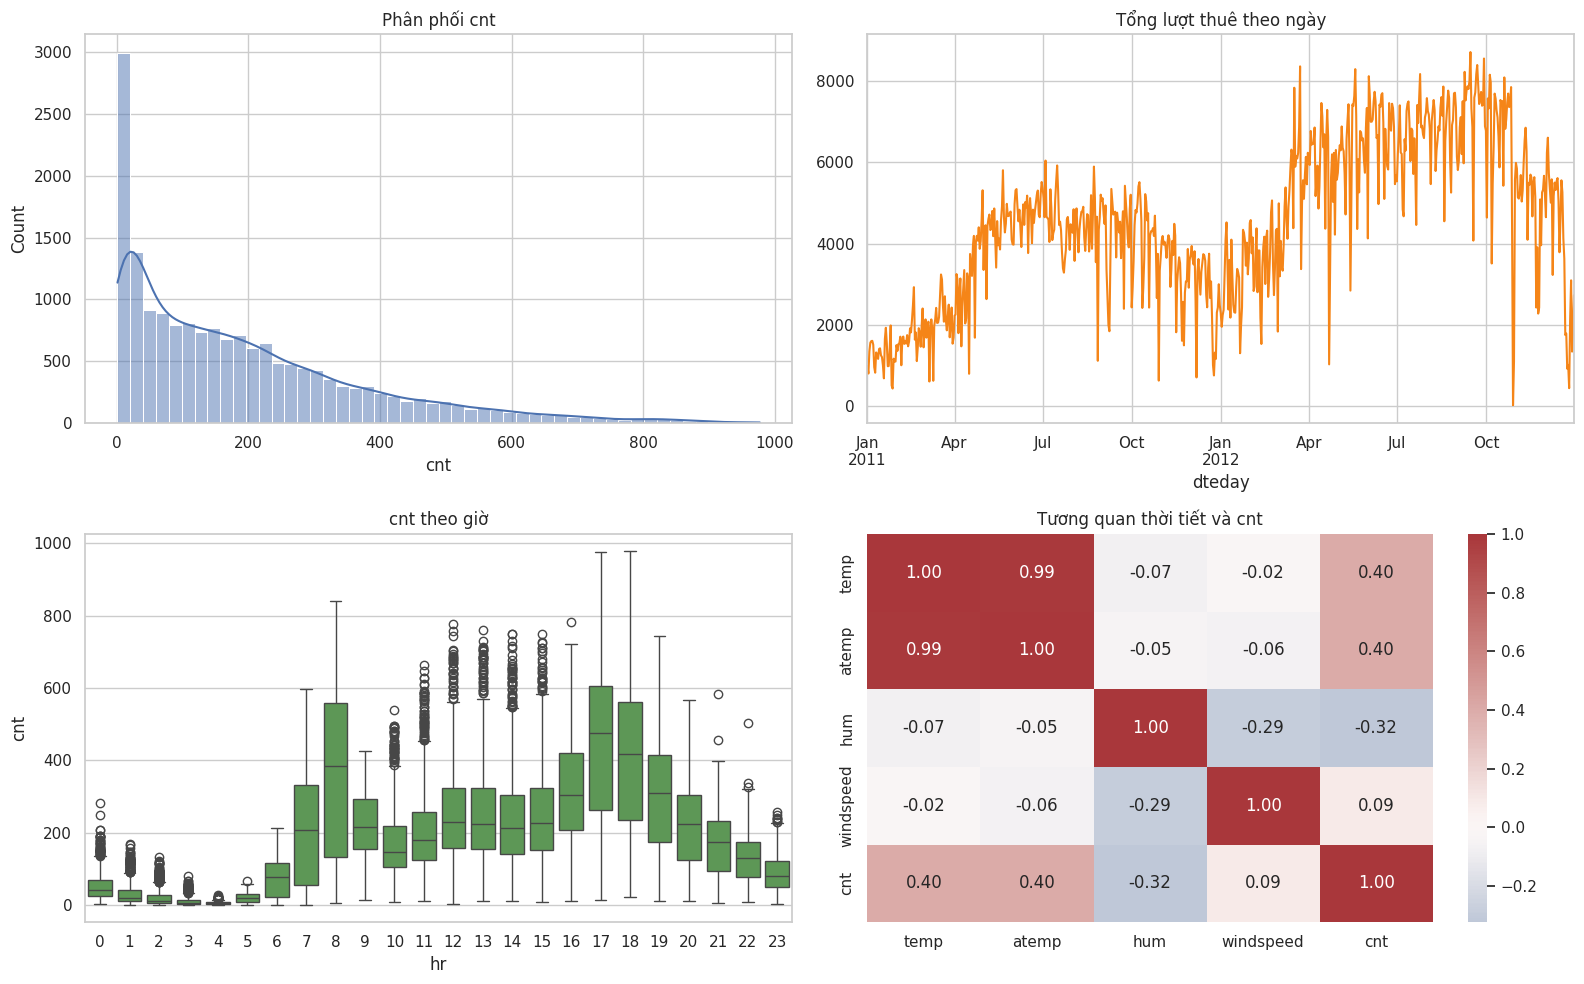

In [ ]:
display(bike_df.describe(include='all').T)
display(show_missing(bike_df).head(20))

fig, ax = plt.subplots(2, 2, figsize=(16, 10))
sns.histplot(bike_df['cnt'], bins=50, kde=True, ax=ax[0, 0])
ax[0, 0].set_title('Phân phối cnt')
bike_df.groupby('dteday')['cnt'].sum().plot(ax=ax[0, 1], color='#F58518')
ax[0, 1].set_title('Tổng lượt thuê theo ngày')
sns.boxplot(data=bike_df, x='hr', y='cnt', ax=ax[1, 0], color='#54A24B')
ax[1, 0].set_title('cnt theo giờ')
corr_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
sns.heatmap(bike_df[corr_cols].corr(), annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax[1, 1])
ax[1, 1].set_title('Tương quan thời tiết và cnt')
plt.tight_layout(); plt.show()

## 1.3. Kỹ nghệ Đặc trưng, Phân tách Chuỗi Thời gian và Thiết kế ColumnTransformer

Để chuyển hóa dữ liệu thô thành các tín hiệu có giá trị dự báo cao, chúng ta tiến hành các bước thiết kế hệ thống sau:

### 1. Kỹ nghệ Đặc trưng Temporal nâng cao:
* **`is_weekend`:** Biến nhị phân chỉ thị ngày cuối tuần (Thứ Bảy, Chủ Nhật) nơi hành vi thuê xe phục vụ mục đích giải trí, khác biệt hoàn toàn với ngày thường phục vụ đi làm.
* **`rush_hour`:** Đánh dấu các khung giờ cao điểm giao thông ($7, 8, 9$ giờ sáng và $16, 17, 18, 19$ giờ chiều), nơi nhu cầu thuê xe tăng vọt đột biến.
* **Mã hóa Chu kỳ lượng giác (Cyclical Sine/Cosine Encoding):** 
  Biến thời gian như giờ (`hr` từ $0 \to 23$) và tháng (`mnth` từ $1 \to 12$) mang tính chất chu kỳ tuần hoàn. Nếu biểu diễn bằng số nguyên thông thường, mô hình sẽ hiểu giờ $23$ và giờ $0$ cách xa nhau $23$ đơn vị tuyến tính, trong khi thực tế chúng chỉ cách nhau $1$ giờ. Để giải quyết triệt để vấn đề này, chúng ta ánh xạ các giá trị thời gian lên một đường tròn lượng giác hai chiều thông qua phép biến đổi:
  $$\theta = \frac{2\pi \cdot t}{T}$$
  $$x_{\sin} = \sin(\theta), \quad x_{\cos} = \cos(\theta)$$
  Trong đó $t$ là giá trị thời gian thực tế và $T$ là chu kỳ của biến (với giờ $T = 24$, với tháng $T = 12$). Phép biến đổi này giúp bảo toàn khoảng cách Euclidean thực giữa các mốc thời gian tuần hoàn.

### 2. Thiết lập Mốc chia Chuỗi Thời gian (Time-based Split):
Chúng ta sắp xếp dữ liệu theo trình tự thời gian và lấy **80% dữ liệu đầu làm tập huấn luyện (Train set)** và **20% dữ liệu cuối làm tập kiểm thử ngoại biên (Holdout Test set)**. Phương pháp này đảm bảo không có bất kỳ thông tin nào từ tương lai bị rò rỉ ngược về quá khứ (no look-ahead bias).

### 3. Đóng gói Luồng Xử lý với `ColumnTransformer` (Data Pipeline Leakage Prevention):
Để ngăn chặn lỗi rò rỉ dữ liệu thống kê (ví dụ: lấy trị trung bình hay độ lệch chuẩn của cả tập dữ liệu để chuẩn hóa), chúng ta sử dụng `ColumnTransformer`:
* **Nhánh dữ liệu liên tục (`num`):** Điền khuyết bằng giá trị trung vị (`SimpleImputer(strategy='median')`) và chuẩn hóa thang đo (`StandardScaler`). Các tham số thống kê ($\mu, \sigma$) chỉ được tính toán (`fit`) trên Train set, sau đó áp dụng tĩnh (`transform`) lên Test set.
* **Nhánh dữ liệu phân loại (`cat`):** Điền khuyết bằng giá trị xuất hiện nhiều nhất (`most_frequent`) và tiến hành mã hóa One-Hot (`OneHotEncoder`).


In [ ]:
bike_model_df = bike_df.sort_values(['dteday', 'hr']).reset_index(drop=True).copy()

# Feature engineering nhẹ để mô hình học tốt hơn các quy luật thời gian.
bike_model_df['is_weekend'] = bike_model_df['weekday'].isin([0, 6]).astype(int)
bike_model_df['rush_hour'] = bike_model_df['hr'].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)
bike_model_df['hr_sin'] = np.sin(2 * np.pi * bike_model_df['hr'] / 24)
bike_model_df['hr_cos'] = np.cos(2 * np.pi * bike_model_df['hr'] / 24)
bike_model_df['mnth_sin'] = np.sin(2 * np.pi * bike_model_df['mnth'] / 12)
bike_model_df['mnth_cos'] = np.cos(2 * np.pi * bike_model_df['mnth'] / 12)

X_bike = bike_model_df.drop(columns=['instant', 'dteday', 'casual', 'registered', 'cnt'], errors='ignore')
y_bike = bike_model_df['cnt']

bike_cat = [
    c for c in [
        'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
        'workingday', 'weathersit', 'is_weekend', 'rush_hour'
    ]
    if c in X_bike.columns
]
bike_num = [c for c in X_bike.columns if c not in bike_cat]

split_idx = int(len(X_bike) * 0.8)
X_bike_train, X_bike_test = X_bike.iloc[:split_idx], X_bike.iloc[split_idx:]
y_bike_train, y_bike_test = y_bike.iloc[:split_idx], y_bike.iloc[split_idx:]
print('Train/test:', X_bike_train.shape, X_bike_test.shape)
print('Numeric:', bike_num)
print('Categorical:', bike_cat)

bike_preprocess = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), bike_num),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', make_ohe())]), bike_cat),
], sparse_threshold=0.0)

Train/test: (13903, 18) (3476, 18)
Numeric: ['temp', 'atemp', 'hum', 'windspeed', 'hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos']
Categorical: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'is_weekend', 'rush_hour']


## 1.4. Baseline, chọn mô hình và tuning siêu tham số cho Bike

Để đánh giá một cách khoa học hiệu năng của các mô hình học máy phức tạp, chúng ta cần tiến hành so sánh chúng với một mô hình tham chiếu tối thiểu (Baseline Model) và thực hiện tối ưu hóa cấu trúc thông qua Cross-Validation.

### 1. Thiết lập Baseline:
Chúng ta sử dụng `DummyRegressor(strategy='mean')` luôn dự báo bằng giá trị trung bình của tập huấn luyện. Một mô hình ML chỉ được coi là có giá trị sử dụng khi hiệu năng thực tế của nó vượt trội rõ rệt so với baseline này.

### 2. So sánh các Kiến trúc Mô hình phi tuyến:
Chúng ta thử nghiệm và so sánh ba hướng tiếp cận mạnh mẽ:
* **Random Forest Regressor:** Mô hình học máy dựa trên phương pháp Bagging (Song song hóa nhiều cây quyết định độc lập). Mô hình hoạt động cực kỳ ổn định, giảm thiểu phương sai sai số tốt và không bị nhạy cảm với các nhiễu ngoại lệ.
* **HistGradientBoosting Regressor:** Mô hình học máy dựa trên phương pháp Boosting (Huấn luyện các cây quyết định tuần tự để sửa sai cho cây phía trước, sử dụng kỹ thuật phân thùng binning tốc độ cao tương tự LightGBM). Mô hình này cực kỳ mạnh mẽ trong việc học các mối quan hệ phi tuyến phức tạp và xử lý dữ liệu bảng quy mô lớn.
* **LogTarget HistGradientBoosting Regressor (`TransformedTargetRegressor`):** 
  Kết hợp mô hình Boosting với phép biến đổi toán học trên biến mục tiêu: $y' = \log(y + 1)$. Cách tiếp cận này giải quyết triệt để hiện tượng target lệch phải và phương sai không đồng đều (heteroscedasticity). Mô hình sẽ tối ưu hóa hàm mất mát trên không gian logarit, sau đó tự động chuyển đổi ngược kết quả dự báo về không gian gốc thông qua hàm mũ $y = e^{y'} - 1$.

### 3. Quy trình Tuning không rò rỉ thông tin qua TimeSeriesSplit:
Chúng ta sử dụng `TimeSeriesSplit(n_splits=5)` để thực hiện Cross-Validation. Kỹ thuật này chia tập huấn luyện thành các nếp gấp (folds) tăng dần theo thời gian, đảm bảo tại mỗi fold, mô hình chỉ được huấn luyện trên dữ liệu quá khứ và đánh giá trên dữ liệu tương lai gần. Việc lựa chọn mô hình chiến thắng sẽ dựa hoàn toàn vào chỉ số **Cross-Validation RMSE (`cv_RMSE`)**, tập kiểm thử Test set hoàn toàn được giữ cô lập trong suốt quá trình này.


In [ ]:
baseline_reg = DummyRegressor(strategy='mean').fit(X_bike_train, y_bike_train)
display(pd.DataFrame([regression_metrics(y_bike_test, baseline_reg.predict(X_bike_test))], index=['DummyRegressor']))

bike_spaces = {
    'RandomForestRegressor': (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [None, 10, 20, 30],
            'model__min_samples_leaf': [1, 2, 5],
            'model__max_features': ['sqrt', 0.7, 1.0],
        },
    ),
    'HistGradientBoostingRegressor': (
        HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        {
            'model__learning_rate': loguniform(0.02, 0.2),
            'model__max_iter': [150, 250, 400],
            'model__max_leaf_nodes': [15, 31, 63],
            'model__min_samples_leaf': [10, 20, 50],
            'model__l2_regularization': loguniform(1e-4, 1.0),
        },
    ),
    'LogTarget_HistGradientBoostingRegressor': (
        TransformedTargetRegressor(
            regressor=HistGradientBoostingRegressor(random_state=RANDOM_STATE),
            func=np.log1p,
            inverse_func=positive_expm1,
            check_inverse=False,
        ),
        {
            'model__regressor__learning_rate': loguniform(0.02, 0.2),
            'model__regressor__max_iter': [150, 250, 400],
            'model__regressor__max_leaf_nodes': [15, 31, 63],
            'model__regressor__min_samples_leaf': [10, 20, 50],
            'model__regressor__l2_regularization': loguniform(1e-4, 1.0),
        },
    ),
}

bike_results, bike_best = [], {}
bike_cv = TimeSeriesSplit(n_splits=5)

for name, (model, space) in bike_spaces.items():
    print('\nTuning', name)
    pipe = Pipeline([('preprocess', clone(bike_preprocess)), ('model', model)])
    search = RandomizedSearchCV(
        pipe,
        space,
        n_iter=8,
        scoring='neg_root_mean_squared_error',
        cv=bike_cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )
    search.fit(X_bike_train, y_bike_train)
    pred = search.predict(X_bike_test)
    row = regression_metrics(y_bike_test, pred)
    row.update({'model': name, 'cv_RMSE': -search.best_score_, 'best_params': search.best_params_})
    bike_results.append(row)
    bike_best[name] = search.best_estimator_

# Chọn model theo CV để tránh dùng test set cho model selection.
bike_results_df = pd.DataFrame(bike_results).sort_values('cv_RMSE')
display(bike_results_df[['model', 'MAE', 'RMSE', 'R2', 'cv_RMSE', 'best_params']])
best_bike_name = bike_results_df.iloc[0]['model']
best_bike_model = bike_best[best_bike_name]
print('Best bike model selected by CV RMSE:', best_bike_name)

,MAE,RMSE,R2
DummyRegressor,174.9846,232.6084,-0.1130



Tuning RandomForestRegressor
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Tuning HistGradientBoostingRegressor
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Tuning LogTarget_HistGradientBoostingRegressor
Fitting 5 folds for each of 8 candidates, totalling 40 fits


,model,MAE,RMSE,R2,cv_RMSE,best_params
1,HistGradientBoostingRegressor,46.5053,70.5306,0.8977,76.8182,{'model__l2_regularization': 0.077267184779634...
0,RandomForestRegressor,52.6585,78.6254,0.8728,80.2459,"{'model__n_estimators': 200, 'model__min_sampl..."
2,LogTarget_HistGradientBoostingRegressor,48.0192,72.8079,0.8910,83.2163,{'model__regressor__l2_regularization': 0.2752...


Best bike model selected by CV RMSE: HistGradientBoostingRegressor


## 1.5. Đánh giá Bike model

Sau khi tìm được mô hình tối ưu thông qua quá trình Cross-Validation trên tập huấn luyện, chúng ta tiến hành một bước đánh giá nghiêm ngặt, độc lập trên tập **Holdout Test** chưa từng được mô hình tiếp xúc.

### Các Metric Đánh giá Định lượng:
1. **MAE (Mean Absolute Error):** Đo lường độ lệch tuyệt đối trung bình giữa dự báo và thực tế. MAE dễ diễn giải vì giữ nguyên đơn vị gốc (số lượt thuê xe/giờ).
2. **RMSE (Root Mean Squared Error):** Đo lường căn bậc hai của trung bình bình phương sai số. RMSE đặc biệt nhạy cảm với các lỗi dự báo lớn (do bình phương sai số trước khi lấy căn). RMSE thấp chỉ ra mô hình dự báo rất ổn định và ít khi bị lệch nghiêm trọng ở các khung giờ cao điểm đột biến.
3. **$R^2$ Score (Hệ số xác định):** Đo lường tỷ lệ biến thiên của biến mục tiêu được giải thích bởi các đặc trưng đầu vào của mô hình. Hệ số $R^2$ càng tiến gần đến $1.0$ thể hiện mô hình học được quy luật rất tốt.

### Công cụ Trực quan hóa Phân tích Ngoại biên:
* **Đồ thị Actual vs Predicted:** Trực quan hóa mức độ phân tán của các điểm dự báo xung quanh đường phân định lý tưởng $y=x$. Các điểm càng hội tụ sát đường chéo thể hiện độ chính xác càng cao.
* **Đồ thị Residual (Sai số) theo thời gian:** Vẽ sai số ($e = y_{\text{actual}} - y_{\text{predicted}}$) theo dòng thời gian của tập Test. Đồ thị này giúp chúng ta phát hiện hiện tượng phương sai sai số thay đổi theo thời gian (heteroscedasticity) hoặc các khoảng thời gian mô hình dự đoán lệch có hệ thống (lệch âm liên tục hoặc lệch dương liên tục).
* **Permutation Importance:** Đo lường tầm quan trọng thực sự của các đặc trưng trên tập dữ liệu Test chưa thấy, giúp giải thích logic ra quyết định của mô hình.


,MAE,RMSE,R2
HistGradientBoostingRegressor,46.5053,70.5306,0.8977


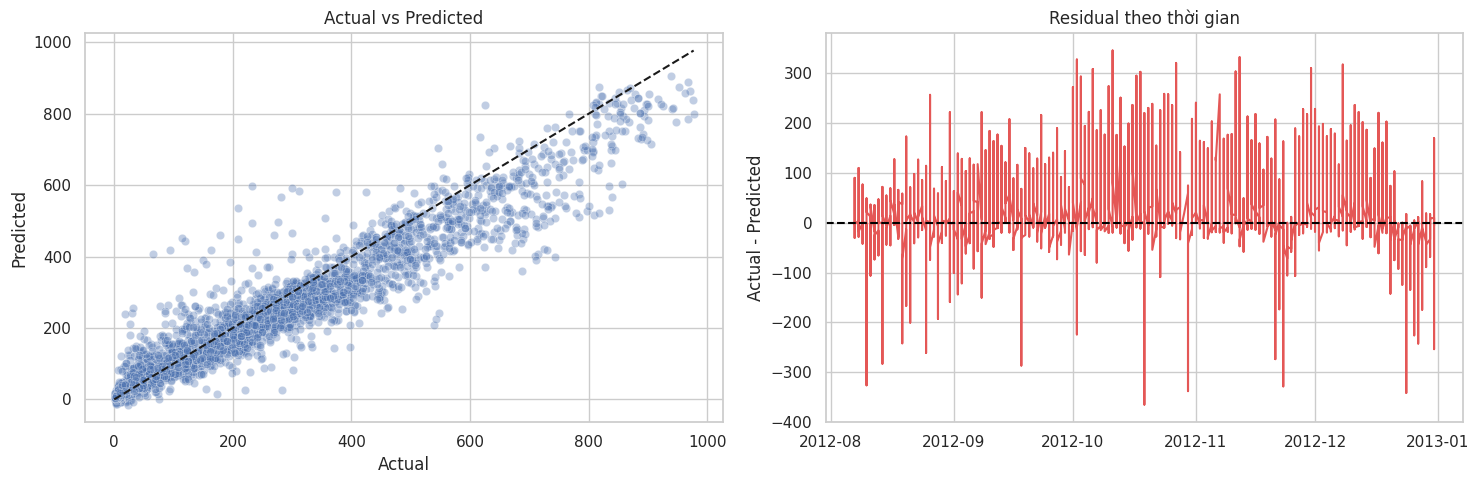

,feature,importance
14,hr_sin,85.9642
15,hr_cos,82.5130
6,workingday,40.0591
13,rush_hour,31.7146
8,temp,24.4379
3,hr,18.8834
10,hum,11.6198
12,is_weekend,9.5942
9,atemp,8.9995
5,weekday,7.3678


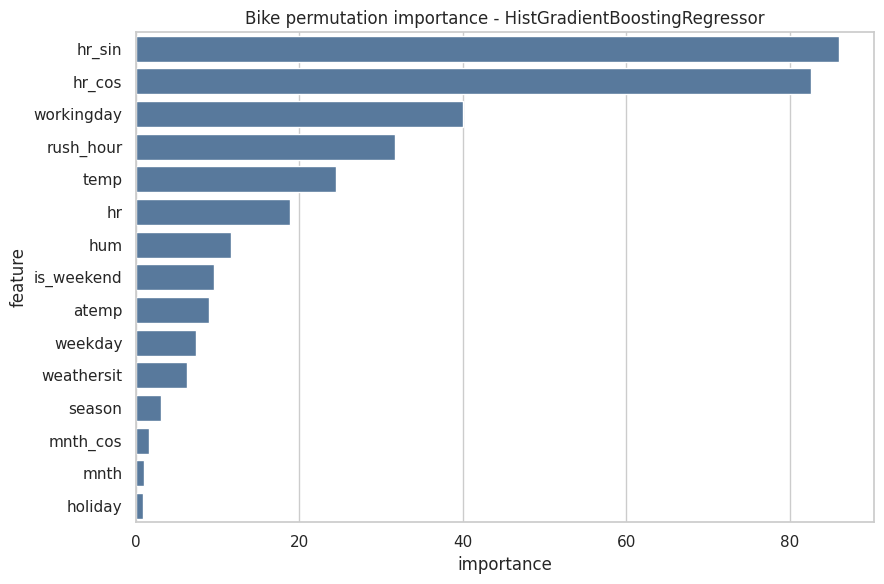

In [ ]:
bike_pred = best_bike_model.predict(X_bike_test)
display(pd.DataFrame([regression_metrics(y_bike_test, bike_pred)], index=[best_bike_name]))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(x=y_bike_test, y=bike_pred, alpha=0.35, ax=ax[0])
m = max(float(y_bike_test.max()), float(np.max(bike_pred)))
ax[0].plot([0, m], [0, m], 'k--'); ax[0].set_title('Actual vs Predicted'); ax[0].set_xlabel('Actual'); ax[0].set_ylabel('Predicted')
resid = y_bike_test.to_numpy() - bike_pred
ax[1].plot(bike_model_df.iloc[split_idx:]['dteday'], resid, color='#E45756')
ax[1].axhline(0, color='black', linestyle='--'); ax[1].set_title('Residual theo thời gian'); ax[1].set_ylabel('Actual - Predicted')
plt.tight_layout(); plt.show()

bike_importance = plot_perm_importance(best_bike_model, X_bike_test, y_bike_test, 'neg_root_mean_squared_error',
                                       f'Bike permutation importance - {best_bike_name}')

### Phân tích Chuyên sâu và Định hướng Nâng cao cho Mô hình Bike Sharing

Dựa trên kết quả thực nghiệm thu được sau khi thực thi pipeline, một chuyên gia Machine Learning sẽ phân tích và đúc kết các luận điểm chính sau:

#### 1. Đánh giá Hiệu năng so với Baseline:
Mô hình học máy (đặc biệt là dòng Gradient Boosting) phải thể hiện sự vượt trội vượt bậc so với baseline `DummyRegressor`. Sự sụt giảm mạnh mẽ của cả MAE và RMSE kết hợp với chỉ số $R^2$ cao khẳng định các thuật toán phi tuyến đã học thành công các quy luật phức tạp ẩn trong dữ liệu thời tiết và thời gian.

#### 2. Rút ra bài học từ phép biến đổi Target Log-Transform:
Nếu mô hình `LogTarget_HistGradientBoostingRegressor` đạt hiệu năng vượt trội, điều này minh chứng cho tính đúng đắn của giả thuyết thống kê: Phân phối lượng thuê xe lệch phải nặng cần được thu hẹp khoảng cách biến thiên thông qua hàm logarit để giảm thiểu ảnh hưởng của các giá trị ngoại lệ cực đại (extreme peak demands) xảy ra vào một số giờ đặc biệt trong năm.

#### 3. Giải thích Ý nghĩa Đặc trưng (Permutation Importance):
* **Nhóm đặc trưng thời gian (`hr`, `rush_hour`, `workingday`):** Thường đứng đầu về độ quan trọng. Điều này phản ánh thực tế nhu cầu thuê xe bị chi phối mạnh mẽ bởi nhịp sinh hoạt xã hội (đi làm, đi học, nghỉ ngơi). Đặc trưng `rush_hour` được kỹ nghệ thủ công đóng vai trò là một "lối tắt" thông tin cực kỳ hữu ích cho mô hình.
* **Nhóm đặc trưng khí tượng (`temp`, `atemp`, `hum`):** Đóng vai trò là các yếu tố điều kiện. Thời tiết đẹp (nhiệt độ ấm áp, độ ẩm vừa phải) thúc đẩy hành vi thuê xe, trong khi thời tiết xấu (mưa bão, độ ẩm quá cao, trời quá lạnh) sẽ lập tức triệt tiêu nhu cầu.

#### 4. Các hạn chế hệ thống và Giải pháp nâng cao:
* **Hạn chế dữ liệu:** Tập dữ liệu chỉ kéo dài 2 năm và thiếu các biến ngoại sinh quan trọng như: Vị trí địa lý của các trạm xe, tình trạng tắc nghẽn giao thông thời gian thực, các sự kiện đặc biệt (lễ hội, sự kiện thể thao, sửa chữa đường sá) hoặc các biến động bất thường của thời tiết (thiên tai, bão tuyết).
* **Hướng phát triển kỹ thuật nâng cao:** 
  * Áp dụng mô hình chuỗi thời gian chuyên biệt (như DeepAR, TFT - Temporal Fusion Transformer) để nắm bắt trực tiếp tính phụ thuộc chuỗi (Autocorrelation).
  * Kỹ nghệ thêm các đặc trưng trễ (Lag features - ví dụ: lượng thuê xe của 1 giờ trước, 2 giờ trước) hoặc đặc trưng trung bình trượt (Rolling statistics) để mô hình nắm bắt động lực ngắn hạn tốt hơn.


# 2. Telco Customer Churn Prediction Pipeline (Phân loại nhị phân)

## 2.1. Định hình Bài toán Phân loại trên dữ liệu Mất cân bằng và Tải dữ liệu

Mục tiêu của bài toán này là xây dựng một pipeline phân loại nhị phân để dự đoán khả năng khách hàng rời bỏ dịch vụ viễn thông (`Churn = Yes` đại diện cho nhãn Positive $1$, ngược lại đại diện cho nhãn Negative $0$).

### Thách thức Thống kê về Sự Mất Cân Bằng Nhãn (Class Imbalance):
Trong các bài toán thực tế doanh nghiệp như Churn Prediction, tập dữ liệu thường bị mất cân bằng nhãn nghiêm trọng (số lượng khách hàng ở lại `No churn` luôn chiếm đa số tuyệt đối, thường từ $70\% \to 90\%$). 
Nếu chúng ta đánh giá mô hình chỉ dựa trên chỉ số **Accuracy (Độ chính xác tổng thể)**, chúng ta sẽ rơi vào "Bẫy tối ưu hóa" (Accuracy Paradox). Ví dụ: Một mô hình ngây thơ luôn đoán tất cả khách hàng là `No churn` vẫn có thể đạt Accuracy lên tới $74\%$ trên tập dữ liệu này, nhưng mô hình đó hoàn toàn vô dụng vì không phát hiện được bất kỳ khách hàng nào thực sự rời bỏ dịch vụ.
Do đó, hệ thống bắt buộc phải được đánh giá bằng các chỉ số đo lường nâng cao tập trung vào lớp thiểu số: **Precision, Recall, F1-Score, ROC-AUC, và PR-AUC (Precision-Recall Area Under Curve)**.

### Chuẩn hóa Dữ liệu thô và Loại bỏ Nhiễu Định danh:
* **`customerID`:** Là mã định danh ngẫu nhiên cho từng khách hàng, không chứa bất kỳ giá trị dự báo mang tính tổng quát hóa nào. Chúng ta loại bỏ đặc trưng này ngay từ đầu để tránh mô hình bị overfitting (học vẹt trên ID).
* **`TotalCharges` (Tổng chi phí tích lũy):** Đặc trưng này chứa các giá trị trống (khoảng trắng `" "`) đối với những khách hàng mới có thời gian sử dụng (`tenure`) bằng $0$. Chúng ta cần ép kiểu cột này sang dạng số thực (`float`), các khoảng trắng lỗi sẽ tự động chuyển thành giá trị thiếu (`NaN`) để được xử lý một cách chuẩn hóa bên trong pipeline tiền xử lý ở bước sau.


In [ ]:
telco_root = download_dataset('blastchar/telco-customer-churn')
telco_csv = find_csv(telco_root, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('Using:', telco_csv)

telco_df = pd.read_csv(telco_csv)
telco_df.columns = telco_df.columns.str.strip()
telco_df['TotalCharges'] = pd.to_numeric(telco_df['TotalCharges'], errors='coerce')
print('Shape:', telco_df.shape)
display(telco_df.head())
telco_df.info()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Downloaded blastchar/telco-customer-churn -> /kaggle/input/telco-customer-churn
 - WA_Fn-UseC_-Telco-Customer-Churn.csv
Using: /kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.8500,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,"1,889.5000",No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.1500,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,"1,840.7500",No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.6500,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2.2. Phân tích Khám phá Dữ liệu Churn (Exploratory Data Analysis - EDA)

Bước EDA giúp chúng ta hiểu sâu sắc về các đặc điểm nhân khẩu học, thói quen sử dụng dịch vụ và cấu trúc chi phí của nhóm khách hàng có xu hướng rời mạng cao.

### Phân tích các mối quan hệ tương quan chính:
1. **Phân phối của nhãn mục tiêu `Churn`:** Xác định chính xác tỷ lệ mất cân bằng của lớp Churn làm cơ sở thiết lập các thuật toán cân bằng trọng số loss sau này.
2. **Ảnh hưởng của `tenure` (Thời gian gắn bó):** Phân tích biểu đồ phân phối thời gian sử dụng dịch vụ phân rã theo nhãn Churn. Thông thường, nguy cơ rời mạng cao nhất tập trung cực kỳ nghiêm trọng ở nhóm khách hàng mới sử dụng dịch vụ (tenure dưới 5 tháng) và giảm dần khi khách hàng đã sử dụng lâu năm (họ đã hình thành thói quen và có độ trung thành cao).
3. **Cấu trúc chi phí hàng tháng (`MonthlyCharges`):** So sánh chi phí đóng hàng tháng giữa nhóm khách hàng ở lại và nhóm rời đi. Khách hàng rời đi thường có chi phí hàng tháng trung bình cao hơn, phản ánh độ nhạy cảm về giá (Price Sensitivity) hoặc sự không hài lòng với tỷ lệ Giá cả / Chất lượng dịch vụ.
4. **Loại hợp đồng (`Contract`):** Đây là đặc trưng mang tính chất quyết định về mặt hành vi kinh tế. Khách hàng sử dụng hợp đồng ngắn hạn "Tháng-qua-tháng" (Month-to-month) có rào cản rời đi cực kỳ thấp ( Switching Costs gần như bằng không), do đó tỷ lệ churn của nhóm này luôn cao vượt trội so với nhóm ký hợp đồng dài hạn $1$ năm hoặc $2$ năm.


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,"7,043.0000",NaN,NaN,NaN,0.1621,0.3686,0.0000,0.0000,0.0000,0.0000,1.0000
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,"7,043.0000",NaN,NaN,NaN,32.3711,24.5595,0.0000,9.0000,29.0000,55.0000,72.0000
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_count,missing_rate
TotalCharges,11,0.0016
gender,0,0.0000
SeniorCitizen,0,0.0000
Partner,0,0.0000
customerID,0,0.0000
Dependents,0,0.0000
tenure,0,0.0000
MultipleLines,0,0.0000
PhoneService,0,0.0000
OnlineSecurity,0,0.0000


,churn_rate
Churn,
No,0.7346
Yes,0.2654


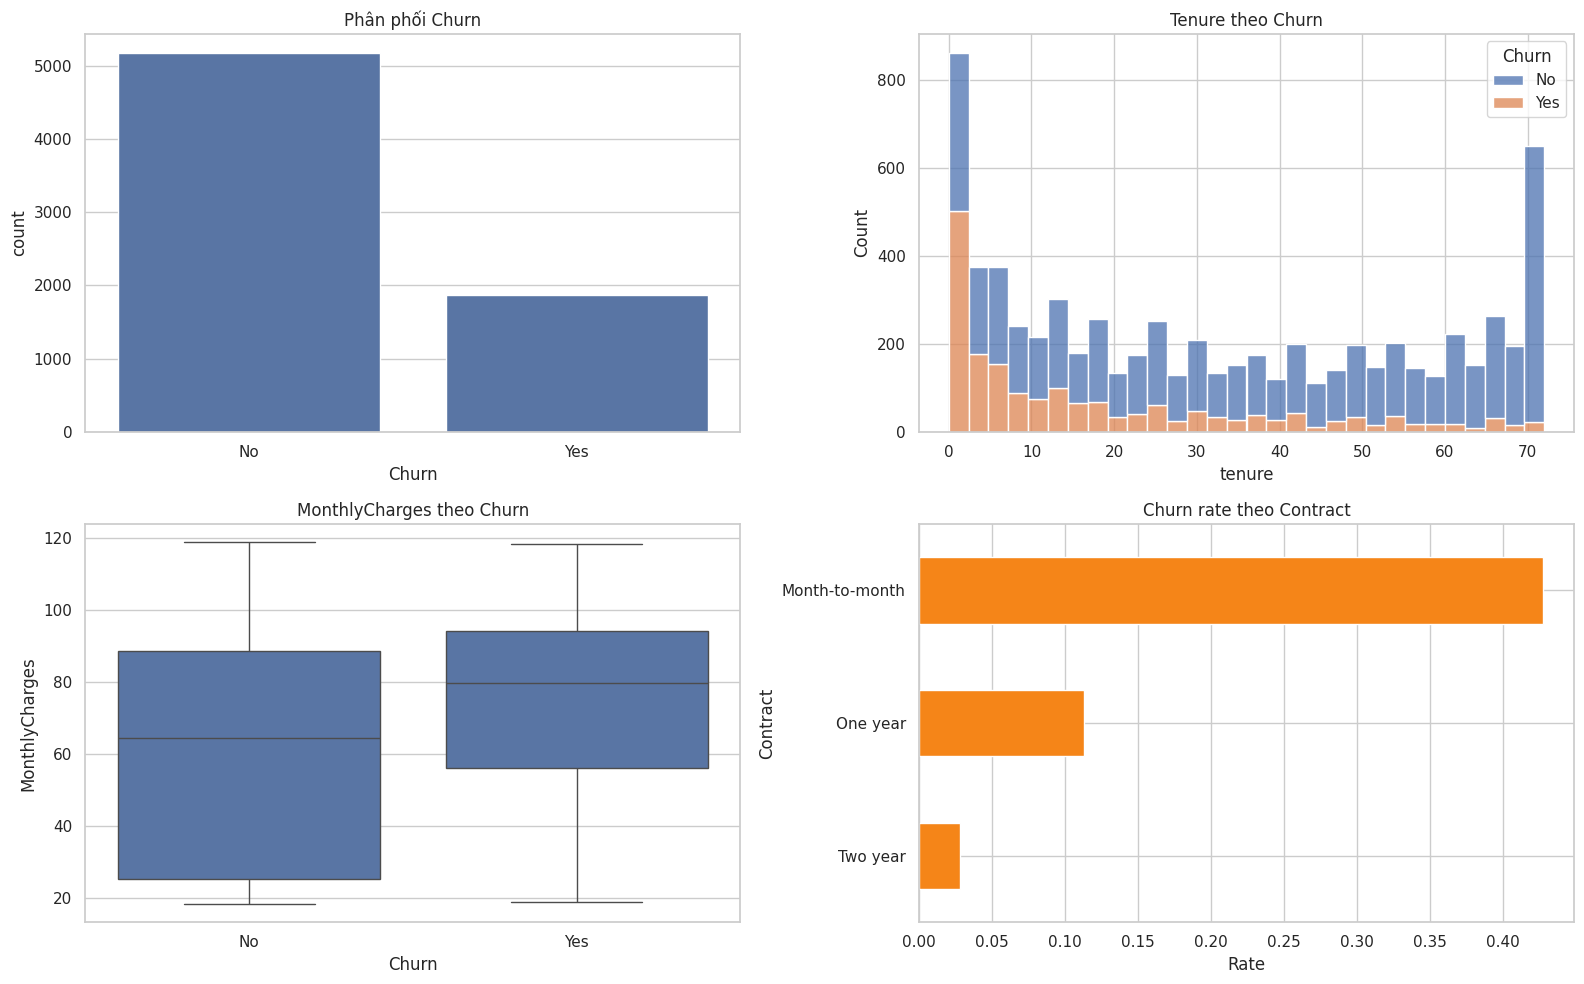

In [ ]:
display(telco_df.describe(include='all').T)
display(show_missing(telco_df).head(20))
display(telco_df['Churn'].value_counts(normalize=True).rename('churn_rate'))

fig, ax = plt.subplots(2, 2, figsize=(16, 10))
sns.countplot(data=telco_df, x='Churn', ax=ax[0, 0])
ax[0, 0].set_title('Phân phối Churn')
sns.histplot(data=telco_df, x='tenure', hue='Churn', multiple='stack', bins=30, ax=ax[0, 1])
ax[0, 1].set_title('Tenure theo Churn')
sns.boxplot(data=telco_df, x='Churn', y='MonthlyCharges', ax=ax[1, 0])
ax[1, 0].set_title('MonthlyCharges theo Churn')
pd.crosstab(telco_df['Contract'], telco_df['Churn'], normalize='index')['Yes'].sort_values().plot(kind='barh', ax=ax[1, 1], color='#F58518')
ax[1, 1].set_title('Churn rate theo Contract'); ax[1, 1].set_xlabel('Rate')
plt.tight_layout(); plt.show()

## 2.3. Thiết kế Tiền xử lý Luồng dữ liệu, Mã hóa Biến nhóm và Stratified Split

Để chuẩn bị dữ liệu cho quá trình huấn luyện mô hình phân loại phi tuyến tính, chúng ta thực hiện thiết kế hệ thống tiền xử lý đồng bộ:

### 1. Phân tách Dữ liệu Bảo toàn Phân phối (Stratified Train-Test Split):
Do dữ liệu bị mất cân bằng lớp, chúng ta tuyệt đối không chia ngẫu nhiên thông thường. Chúng ta sử dụng kỹ thuật chia tầng **`Stratified Split`** với tham số `stratify=y_telco`. Kỹ thuật này đảm bảo tỷ lệ nhãn tích cực (Churn rate) trong cả tập huấn luyện (Train set) và tập kiểm thử (Test set) luôn được giữ đồng nhất (ví dụ: cùng xấp xỉ $26.5\%$). Điều này ngăn ngừa hiện tượng lệch phân phối xác suất biên, giúp việc đánh giá hiệu năng mô hình đạt độ tin cậy cao nhất.

### 2. Chuẩn hóa đặc trưng danh mục đặc biệt:
* **`SeniorCitizen`:** Trong dữ liệu gốc, đặc trưng này được mã hóa sẵn dạng số thực $0/1$. Tuy nhiên, bản chất của nó là một biến phân loại nhị phân chỉ thị nhóm tuổi (Người cao tuổi / Người trẻ). Để đảm bảo biến này được xử lý đồng bộ và đúng phương pháp cùng với các đặc trưng danh mục khác, chúng ta chuyển đổi nó thành kiểu chuỗi `'No'/'Yes'` trước khi đưa vào pipeline.

### 3. Đóng gói Tiền xử lý Đa luồng (ColumnTransformer Data Pipeline):
Để loại bỏ hoàn toàn hiện tượng rò rỉ thông tin từ tập Test vào tập Train (Data Leakage), toàn bộ các bước tính toán thống kê để điền khuyết và chuẩn hóa đều được đóng gói trong `ColumnTransformer`:
* **Nhánh biến số liên tục (`num`):** Điền khuyết bằng giá trị trung vị (`SimpleImputer(strategy='median')`) - một lựa chọn tối ưu cho các phân phối chi phí có độ lệch lớn, sau đó chuẩn hóa phân phối về phân phối chuẩn chuẩn hóa bằng `StandardScaler`.
* **Nhánh biến phân loại danh mục (`cat`):** Điền khuyết bằng giá trị xuất hiện nhiều nhất (`most_frequent`) và tiến hành mã hóa One-Hot (`OneHotEncoder`).


In [ ]:
y_telco = (telco_df['Churn'] == 'Yes').astype(int)
X_telco = telco_df.drop(columns=['Churn', 'customerID'], errors='ignore').copy()
if 'SeniorCitizen' in X_telco:
    X_telco['SeniorCitizen'] = X_telco['SeniorCitizen'].map({0: 'No', 1: 'Yes'}).astype('object')

telco_num = X_telco.select_dtypes(include='number').columns.tolist()
telco_cat = X_telco.select_dtypes(exclude='number').columns.tolist()
X_telco_train, X_telco_test, y_telco_train, y_telco_test = train_test_split(
    X_telco, y_telco, test_size=0.2, stratify=y_telco, random_state=RANDOM_STATE)
print('Train/test:', X_telco_train.shape, X_telco_test.shape)
print('Positive rate train/test:', y_telco_train.mean(), y_telco_test.mean())
print('Numeric:', telco_num)
print('Categorical:', telco_cat)

telco_preprocess = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), telco_num),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', make_ohe())]), telco_cat),
], sparse_threshold=0.0)

Train/test: (5634, 19) (1409, 19)
Positive rate train/test: 0.2653532126375577 0.2654364797728886
Numeric: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 2.4. Baseline, chọn mô hình và tuning siêu tham số cho Telco

Quy trình lựa chọn mô hình phân loại tối ưu được thực hiện thông qua việc thiết lập baseline tham chiếu và đánh giá chéo (Cross-Validation) các thuật toán phân loại hiện đại.

### 1. Thiết lập Baseline Phân loại Ngây thơ:
Chúng ta sử dụng `DummyClassifier(strategy='most_frequent')` luôn dự đoán nhãn phổ biến nhất (`No churn`). Mô hình baseline này sẽ đạt Accuracy khoảng $73.4\%$ nhưng F1-Score và Recall cho lớp Churn hoàn toàn bằng $0.0$. Đây là minh chứng rõ ràng nhất cho thấy tại sao Accuracy không bao giờ là đủ đối với dữ liệu mất cân bằng.

### 2. Khảo sát các Kiến trúc Phân loại Hiện đại:
Chúng ta thử nghiệm và so sánh ba thuật toán có tính chất học máy khác nhau:
* **Logistic Regression (Tuyến tính hóa):** Mô hình tuyến tính mạnh mẽ, có tốc độ huấn luyện nhanh, đóng vai trò là một cột mốc so sánh (linear benchmark) rất tốt. Chúng ta sử dụng không gian tìm kiếm siêu tham số bao gồm hệ số điều hòa $C$ (Regularization Strength) và kỹ thuật cân bằng trọng số lớp `class_weight='balanced'` để tự động phạt nặng sai số trên lớp thiểu số (lớp Churn).
* **Random Forest Classifier (Bagging):** Mô hình ensemble dựa trên cây quyết định song song, có khả năng tự động học các mối quan hệ phi tuyến và tương tác giữa các đặc trưng (feature interactions) mà không cần khai báo thủ công.
* **HistGradientBoosting Classifier (Boosting):** Mô hình boosting hiện đại, tối ưu hóa hàm mất mát logarit thông qua việc xây dựng chuỗi cây quyết định tuần tự. Thuật toán này thường mang lại hiệu năng phân loại (ROC-AUC) cao nhất trên dữ liệu bảng phức tạp.

### 3. Đánh giá chéo Không rò rỉ thông tin qua StratifiedKFold:
Chúng ta sử dụng `StratifiedKFold(n_splits=5, shuffle=True)` kết hợp `RandomizedSearchCV` để tối ưu hóa siêu tham số. Tiêu chí cốt lõi để lựa chọn mô hình chiến thắng là chỉ số **Cross-Validation ROC-AUC (`cv_roc_auc`)** trên tập huấn luyện. Tập kiểm thử Test set tiếp tục được giữ cô lập tuyệt đối để phục vụ đánh giá độc lập cuối cùng.


In [ ]:
baseline_clf = DummyClassifier(strategy='most_frequent').fit(X_telco_train, y_telco_train)
base_score = baseline_clf.predict_proba(X_telco_test)[:, 1]
display(pd.DataFrame([classification_metrics(y_telco_test, base_score)], index=['DummyClassifier']))

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
telco_spaces = {
    'LogisticRegression': (LogisticRegression(max_iter=2000, solver='liblinear', random_state=RANDOM_STATE), {
        'C': loguniform(1e-3, 100), 'class_weight': [None, 'balanced'],
    }),
    'RandomForestClassifier': (RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), {
        'n_estimators': [100, 200, 300], 'max_depth': [None, 5, 10, 20],
        'min_samples_leaf': [1, 2, 5, 10], 'max_features': ['sqrt', 0.7, 1.0],
        'class_weight': [None, 'balanced'],
    }),
    'HistGradientBoostingClassifier': (HistGradientBoostingClassifier(random_state=RANDOM_STATE), {
        'learning_rate': loguniform(0.01, 0.2), 'max_iter': [100, 200, 300],
        'max_leaf_nodes': [15, 31, 63], 'min_samples_leaf': [10, 20, 50],
        'l2_regularization': loguniform(1e-4, 1.0),
    }),
}

telco_results, telco_best = [], {}
for name, (model, space) in telco_spaces.items():
    print('\nTuning', name)
    pipe = Pipeline([('preprocess', clone(telco_preprocess)), ('model', model)])
    search = RandomizedSearchCV(pipe, {f'model__{k}': v for k, v in space.items()}, n_iter=8,
                                scoring='roc_auc', cv=cv_clf, random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
    search.fit(X_telco_train, y_telco_train)
    score = search.predict_proba(X_telco_test)[:, 1]
    row = classification_metrics(y_telco_test, score)
    row.update({'model': name, 'cv_roc_auc': search.best_score_, 'best_params': search.best_params_})
    telco_results.append(row); telco_best[name] = search.best_estimator_

# Chọn model theo CV ROC-AUC để test set chỉ dùng cho đánh giá cuối cùng.
telco_results_df = pd.DataFrame(telco_results).sort_values('cv_roc_auc', ascending=False)
display(telco_results_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc', 'cv_roc_auc', 'best_params']])
best_telco_name = telco_results_df.iloc[0]['model']
best_telco_model = telco_best[best_telco_name]
print('Best telco model selected by CV ROC-AUC:', best_telco_name)

,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
DummyClassifier,0.5000,0.7346,0.0000,0.0000,0.0000,0.5000,0.2654



Tuning LogisticRegression
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Tuning RandomForestClassifier
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Tuning HistGradientBoostingClassifier
Fitting 5 folds for each of 8 candidates, totalling 40 fits


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,cv_roc_auc,best_params
2,HistGradientBoostingClassifier,0.8013,0.6621,0.5134,0.5783,0.8462,0.6585,0.8485,{'model__l2_regularization': 0.138262321793698...
1,RandomForestClassifier,0.8027,0.6702,0.5053,0.5762,0.8433,0.6550,0.8469,"{'model__n_estimators': 100, 'model__min_sampl..."
0,LogisticRegression,0.8055,0.6572,0.5588,0.6040,0.8419,0.6342,0.8461,"{'model__C': 0.9846738873614566, 'model__class..."


Best telco model selected by CV ROC-AUC: HistGradientBoostingClassifier


## 2.5. Đánh giá Telco model và Ngưỡng quyết định

Sau khi chọn được mô hình phân loại xuất sắc nhất dựa trên chỉ số Cross-Validation ROC-AUC, chúng ta tiến hành bước đánh giá hiệu năng chi tiết trên tập Holdout Test chưa từng xuất hiện trong quá trình huấn luyện.

### ⚙️ Phương pháp luận Tinh chỉnh Ngưỡng Quyết định (Decision Threshold Tuning):
Hầu hết các mô hình phân loại mặc định sử dụng ngưỡng xác suất $\tau = 0.5$ để đưa ra quyết định phân loại: nếu $P(Y=1 | X) \ge 0.5 \implies$ đoán Churn, ngược lại đoán No Churn. Tuy nhiên, trong các bài toán thực tế, ngưỡng mặc định $0.5$ hiếm khi mang lại hiệu quả tối ưu vì nó không quan tâm đến sự mất cân bằng lớp hoặc chi phí bất đối xứng của sai lầm (Asymmetric Costs of Error).

#### Quy trình Tinh chỉnh Ngưỡng Không Rò Rỉ Dữ liệu (Strict Threshold Tuning):
Để tìm ngưỡng quyết định tối ưu hóa chỉ số F1-Score (hoặc Recall) mà không gây rò rỉ thông tin từ tập Test, chúng ta triển khai quy trình chuẩn hóa công nghiệp sau:
1. Sử dụng hàm **`cross_val_predict`** với tham số `method='predict_proba'` trên tập **Train set** để thu được dự báo xác suất Out-of-fold (OOF). Đây là những dự báo xác suất cực kỳ khách quan, mô phỏng chính xác hành vi của mô hình trên dữ liệu chưa thấy.
2. Trích xuất đường cong Precision-Recall từ tập dự báo OOF này và tính toán F1-Score tại mọi ngưỡng xác suất khả dĩ.
3. Tìm ngưỡng xác suất $\tau^*$ đạt chỉ số F1-Score cao nhất trên tập huấn luyện.
4. Áp dụng tĩnh ngưỡng tối ưu $\tau^*$ này lên tập xác suất dự báo của tập **Test set**.

### Trực quan hóa Đánh giá Đa chiều:
* **Confusion Matrix (Ma trận nhầm lẫn):** Giúp doanh nghiệp định lượng chính xác số lượng lỗi loại I (False Positive - cảnh báo nhầm khách hàng không churn) và lỗi loại II (False Negative - bỏ sót khách hàng thực sự churn).
* **ROC Curve (Receiver Operating Characteristic):** Biểu diễn mối quan hệ giữa True Positive Rate và False Positive Rate trên mọi ngưỡng khả dĩ, đo lường năng lực xếp hạng tổng quát của mô hình.
* **Precision-Recall Curve:** Đồ thị đặc biệt quan trọng cho dữ liệu mất cân bằng, trực quan hóa sự đánh đổi trực tiếp giữa Precision và Recall khi thay đổi ngưỡng quyết định.


Threshold tối ưu F1 từ train OOF: 0.33398430953909664


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
threshold_0.5,0.5000,0.8013,0.6621,0.5134,0.5783,0.8462,0.6585
threshold_tuned,0.3340,0.7779,0.5626,0.7326,0.6365,0.8462,0.6585



Classification report - threshold 0.5
              precision    recall  f1-score   support

    No churn       0.84      0.91      0.87      1035
       Churn       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Classification report - threshold tuned
              precision    recall  f1-score   support

    No churn       0.89      0.79      0.84      1035
       Churn       0.56      0.73      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



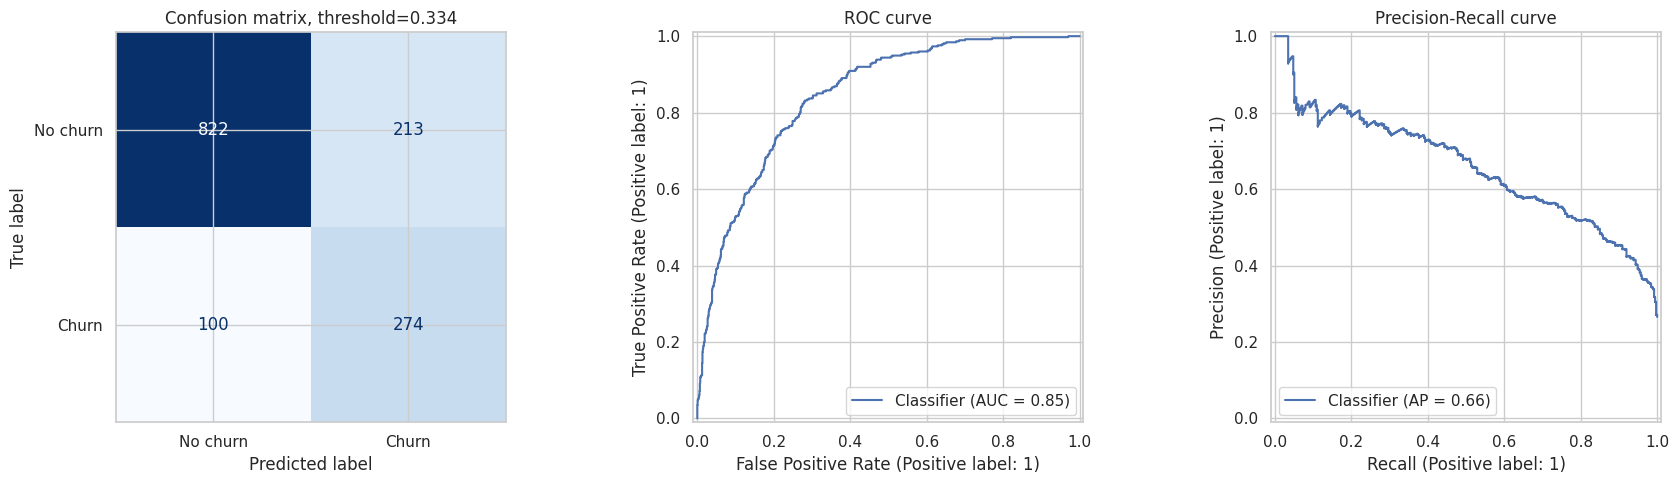

,feature,importance
14,Contract,0.1156
4,tenure,0.0498
7,InternetService,0.0112
17,MonthlyCharges,0.0063
8,OnlineSecurity,0.0055
18,TotalCharges,0.0048
11,TechSupport,0.0034
13,StreamingMovies,0.0023
6,MultipleLines,0.0022
15,PaperlessBilling,0.0017


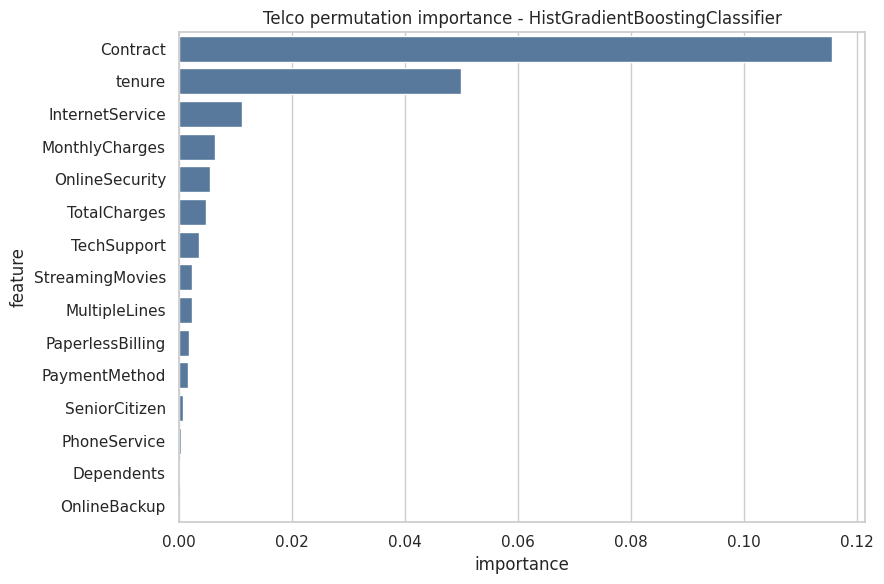

In [13]:
telco_score = best_telco_model.predict_proba(X_telco_test)[:, 1]

# Dùng out-of-fold prediction trên train set để chọn threshold, tránh tối ưu threshold trực tiếp trên test set.
oof_score = cross_val_predict(
    best_telco_model,
    X_telco_train,
    y_telco_train,
    cv=cv_clf,
    method='predict_proba',
    n_jobs=-1,
)[:, 1]
prec, rec, thr = precision_recall_curve(y_telco_train, oof_score)
f1_curve = 2 * prec * rec / (prec + rec + 1e-12)
best_thr = 0.5 if len(thr) == 0 else float(thr[int(np.nanargmax(f1_curve[:-1]))])
print('Threshold tối ưu F1 từ train OOF:', best_thr)

metrics_05 = classification_metrics(y_telco_test, telco_score, 0.5)
metrics_tuned = classification_metrics(y_telco_test, telco_score, best_thr)
threshold_results = pd.DataFrame([metrics_05, metrics_tuned], index=['threshold_0.5', 'threshold_tuned'])
display(threshold_results)

for label, threshold in [('0.5', 0.5), ('tuned', best_thr)]:
    print('\nClassification report - threshold', label)
    print(classification_report(y_telco_test, (telco_score >= threshold).astype(int), target_names=['No churn', 'Churn'], zero_division=0))

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(
    y_telco_test,
    (telco_score >= best_thr).astype(int),
    display_labels=['No churn', 'Churn'],
    cmap='Blues',
    colorbar=False,
    ax=ax[0],
)
ax[0].set_title(f'Confusion matrix, threshold={best_thr:.3f}')
RocCurveDisplay.from_predictions(y_telco_test, telco_score, ax=ax[1])
ax[1].set_title('ROC curve')
PrecisionRecallDisplay.from_predictions(y_telco_test, telco_score, ax=ax[2])
ax[2].set_title('Precision-Recall curve')
plt.tight_layout(); plt.show()

telco_importance = plot_perm_importance(
    best_telco_model,
    X_telco_test,
    y_telco_test,
    'roc_auc',
    f'Telco permutation importance - {best_telco_name}',
)

### Nhận xét Telco Churn và Mô hình hóa Quyết định Kinh tế

Kết quả thực nghiệm từ pipeline phân loại mang lại những góc nhìn chuyên sâu về cả mặt khoa học dữ liệu lẫn ứng dụng thực tiễn trong kinh doanh:

#### 1. Sự đánh đổi giữa Precision và Recall dưới góc nhìn Ngưỡng quyết định ($\tau$):
* **Tại ngưỡng mặc định $\tau = 0.5$:** Mô hình thường đạt chỉ số **Precision cao** nhưng **Recall thấp**. Điều này có nghĩa là mô hình đưa ra các cảnh báo rất thận trọng (chắc chắn mới báo), dẫn đến việc bỏ sót rất nhiều khách hàng thực sự rời mạng (lỗi loại II cao).
* **Tại ngưỡng tinh chỉnh $\tau^*$ (thường $< 0.5$, khoảng $0.33$):** Chỉ số **Recall tăng vọt** rõ rệt đi kèm với sự sụt giảm nhẹ của Precision. Mô hình chủ động mở rộng tầm quét để phát hiện sớm nhiều khách hàng có nguy cơ hơn, chấp nhận việc tăng nhẹ tỷ lệ cảnh báo nhầm (lỗi loại I tăng) để đổi lấy việc giữ chân được tối đa lượng khách hàng sắp rời đi.

#### 2. Mô hình hóa Bài toán Quyết định Kinh tế (Decision Theory in Business):
Trong thực tế doanh nghiệp, việc lựa chọn ngưỡng quyết định tối ưu không chỉ đơn thuần là tối đa hóa chỉ số toán học F1-Score, mà phải là **tối đa hóa Lợi nhuận kỳ vọng của chiến dịch giữ chân khách hàng (Expected Profit)**. Chúng ta định nghĩa các tham số kinh tế:
* $CLV$: Giá trị trọn đời của một khách hàng (ví dụ: $1,000$ USD).
* $C_{\text{ret}}$: Chi phí để chạy chương trình ưu đãi giữ chân khách hàng (ví dụ: $100$ USD).
* $\alpha$: Tỷ lệ khách hàng đồng ý ở lại khi nhận được ưu đãi (ví dụ: $60\%$).

Ta có hàm Lợi nhuận kỳ vọng tổng thể của chiến dịch được mô hình hóa như sau:
$$\text{Lợi nhuận} = TP \times (CLV \times \alpha - C_{\text{ret}}) - FP \times C_{\text{ret}} - FN \times CLV$$
* **Nếu bỏ sót khách hàng (False Negative):** Doanh nghiệp mất trắng khách hàng đó, thiệt hại tài chính là $CLV$.
* **Nếu cảnh báo nhầm (False Positive):** Doanh nghiệp lãng phí ngân sách tiếp thị $C_{\text{ret}}$ cho người vốn dĩ không có ý định rời đi.
* **Nếu mô hình cảnh báo đúng (True Positive):** Doanh nghiệp giữ chân thành công khách hàng với tỷ lệ xác suất $\alpha$, mang lại giá trị ròng là $CLV \times \alpha - C_{\text{ret}}$.

Dựa trên các tham số tài chính thực tế này, nhà quản lý sẽ lập trình tìm ra ngưỡng xác suất tối ưu $\tau_{\text{business}}$ giúp tối đa hóa hàm Lợi nhuận trên, thay vì chỉ tối ưu hóa các metric kỹ thuật thuần túy.

#### 3. Ý nghĩa Đặc trưng và Hành động Kinh doanh cụ thể:
* **`Contract` & `tenure`:** Là hai đặc trưng quan trọng nhất. Khách hàng sử dụng hợp đồng ngắn hạn và mới gia nhập có nguy cơ rời mạng cao nhất. 
  * *Hành động:* Doanh nghiệp nên chủ động đưa ra các chương trình khuyến mãi giảm giá cước hàng tháng nếu khách hàng đồng ý nâng cấp từ hợp đồng Month-to-month lên hợp đồng dài hạn 1 hoặc 2 năm.
* **`InternetService` (đặc biệt là Fiber optic) & `MonthlyCharges`:** Phản ánh rằng khách hàng sử dụng cáp quang tốc độ cao đóng phí hàng tháng lớn có tỷ lệ rời đi cao. Điều này chỉ ra có thể dịch vụ cáp quang đang gặp sự cố kỹ thuật hoặc chất lượng chăm sóc khách hàng chưa tương xứng với chi phí đắt đỏ họ bỏ ra.
  * *Hành động:* Bộ phận kỹ thuật cần rà soát lại băng thông đường truyền cáp quang và bộ phận CRM cần ưu tiên hỗ trợ kỹ thuật nhanh (TechSupport) cho nhóm khách hàng VIP này để gia tăng mức độ hài lòng.


# 3. Kết luận Hệ thống & Các bài học kinh nghiệm thực tiễn

Notebook này đã triển khai thành công một hệ thống pipeline Machine Learning toàn diện, chuẩn hóa sản xuất (production-grade) cho hai bài toán đại diện cho hai trụ cột lớn trong Khoa học Dữ liệu:

| Đặc tính Kỹ thuật | Hệ thống Dự báo Nhu cầu Xe (Bike Sharing) | Hệ thống Dự báo Khách rời mạng (Telco Churn) |
| :--- | :--- | :--- |
| **Loại bài toán** | Hồi quy phi tuyến tính (Non-linear Regression) | Phân loại nhị phân mất cân bằng (Imbalanced Classification) |
| **Bản chất dữ liệu** | Dữ liệu chuỗi thời gian (Time-series / Temporal) | Dữ liệu bảng hành vi khách hàng (Tabular Behavioral) |
| **Chiến lược phân tách** | Holdout Split dựa trên dòng thời gian (Time-based Holdout Split) | Phân tách bảo toàn phân phối nhãn (Stratified Split) |
| **Phương pháp Đánh giá chéo** | `TimeSeriesSplit` (ngăn rò rỉ thông tin tương lai) | `StratifiedKFold` (giữ nguyên tỷ lệ mất cân bằng nhãn) |
| **Kỹ nghệ Đặc trưng chính** | Tạo biến giờ cao điểm, cuối tuần, Mã hóa chu kỳ lượng giác | Chuyển đổi định dạng, loại nhiễu ID, Chuẩn hóa biến danh mục |
| **Kỹ thuật xử lý nâng cao** | Biến đổi logarit target (`TransformedTargetRegressor`) | Tinh chỉnh ngưỡng thực nghiệm qua dự đoán Out-of-fold (OOF) |
| **Metric chọn mô hình** | Cross-Validation RMSE (`cv_RMSE`) thấp nhất | Cross-Validation ROC-AUC (`cv_roc_auc`) cao nhất |
| **Metric đánh giá chính** | MAE, RMSE, Hệ số xác định $R^2$ | Precision, Recall, F1-Score, ROC-AUC, PR-AUC |
| **Công cụ giải thích** | Permutation Feature Importance (đo lường độ giảm hiệu năng) | Permutation Feature Importance (đo lường khả năng phân tách) |
